In [44]:
import pandas as pd

dataset = pd.read_csv('../../datasets/manufacturing.csv')
dataset.head()

,Temperature (°C),Pressure (kPa),Temperature x Pressure,Material Fusion Metric,Material Transformation Metric,Quality Rating
0,209.762701,8.050855,1688.769167,44522.217074,9.229576e+06,99.999971
1,243.037873,15.812068,3842.931469,63020.764997,1.435537e+07,99.985703
2,220.552675,7.843130,1729.823314,49125.950249,1.072839e+07,99.999758
3,208.976637,23.786089,4970.736918,57128.881547,9.125702e+06,99.999975
4,184.730960,15.797812,2918.345014,38068.201283,6.303792e+06,100.000000


In [48]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
pipeline = Pipeline(
    steps=[
        ("Scaler", StandardScaler()),
        ("Polynominal", PolynomialFeatures(degree = 4)),
        ("Model", LinearRegression())
    ]
)

X = dataset.drop(columns=['Quality Rating'])
y = dataset['Quality Rating']

X_train, x_test, Y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

pipeline.fit(X_train, Y_train)

y_preds = pipeline.predict(x_test)
r2 = r2_score(y_test, y_preds)
print(r2)


0.9999695658572588


In [46]:
import seaborn as sns

x_test.columns

Index(['Temperature (°C)', 'Pressure (kPa)', 'Temperature x Pressure',
       'Material Fusion Metric', 'Material Transformation Metric'],
      dtype='object')

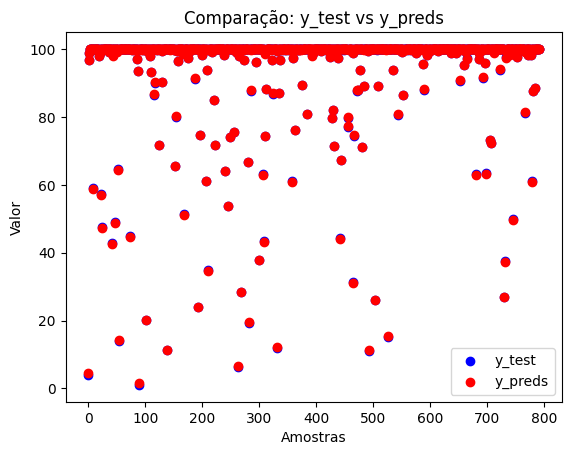

In [49]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(y_test))  # eixo x só para posicionar os pontos

plt.figure()
plt.scatter(x, y_test, label="y_test", color="blue")
plt.scatter(x, y_preds, label="y_preds", color="red")
plt.xlabel("Amostras")
plt.ylabel("Valor")
plt.title("Comparação: y_test vs y_preds")
plt.legend()
plt.show()


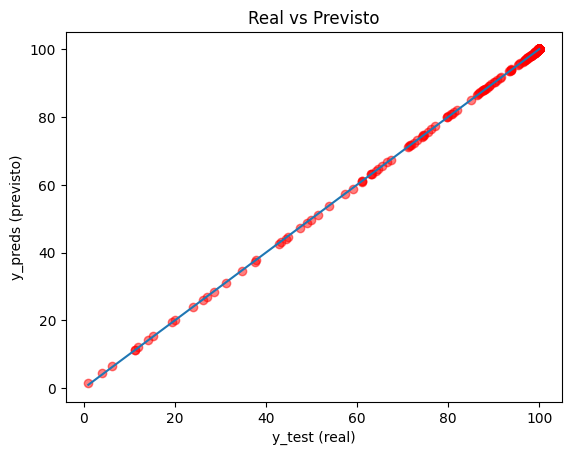

In [53]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_preds, color="Red", alpha= 0.5)
plt.xlabel("y_test (real)")
plt.ylabel("y_preds (previsto)")
plt.title("Real vs Previsto")

# linha ideal
plt.plot([min(y_test), max(y_test)],
         [min(y_test), max(y_test)])
plt.show()


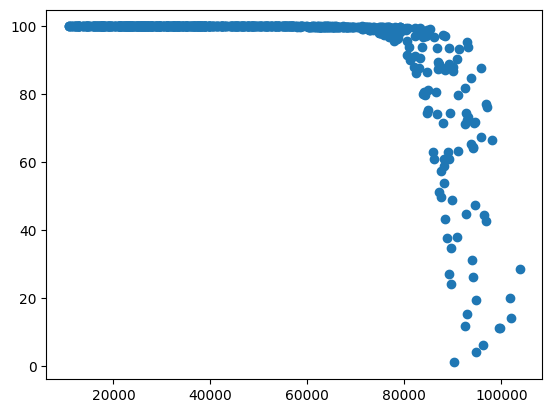

In [ ]:
plt.scatter(x_test['Material Fusion Metric'], y_test);

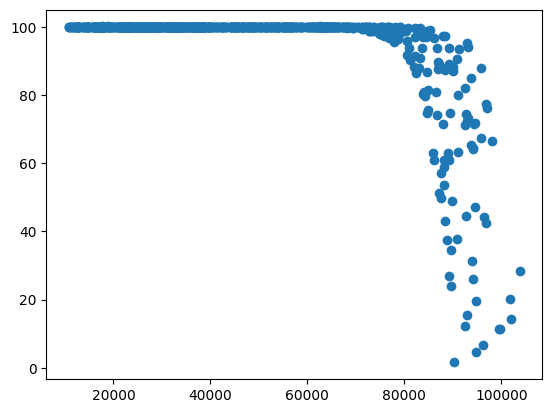

In [56]:
plt.scatter(x_test['Material Fusion Metric'], y_preds);